In [86]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
df = pd.read_csv(
    "student_placement_prediction_dataset_2026.csv"
)

print(df.head())

   student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1             61.699

In [4]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.describe())

(100000, 26)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    1

In [5]:
df.rename(
    columns={
        'placement_status':'interview_result'
    },
    inplace=True
)

print(df.columns)

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'interview_result', 'salary_package_lpa'],
      dtype='str')


In [ ]:
import numpy as np

# -----------------------------
# CORE DERIVED FEATURES (CLEAN VERSION)
# -----------------------------

# Confidence → depends only on communication skill
df['confidence_score'] = (
    df['communication_skill_score']
    + np.random.randint(-8, 8, size=len(df))
).clip(0, 100)


# (OPTIONAL) You can keep teamwork ONLY if leadership_score exists
if 'leadership_score' in df.columns:
    df['teamwork_score'] = (
        df['leadership_score']
        + np.random.randint(-8, 8, size=len(df))
    ).clip(0, 100)


# Professionalism → only if attendance exists
if 'attendance_percentage' in df.columns:
    df['professionalism_score'] = (
        df['attendance_percentage']
        + np.random.randint(-5, 5, size=len(df))
    ).clip(0, 100)


# Behavioral score → REMOVE from final model (but keep for dataset richness)
if 'leadership_score' in df.columns:
    df['behavioral_round_score'] = (
        (df['communication_skill_score'] + df['leadership_score']) / 2
        + np.random.randint(-5, 5, size=len(df))
    ).clip(0, 100)

In [7]:
interview_score = (
      df['coding_skill_score'] * 0.30
    + df['communication_skill_score'] * 0.25
    + df['mock_interview_score'] * 0.25
    + df['aptitude_score'] * 0.10
    + df['logical_reasoning_score'] * 0.10
)

df['interview_result'] = np.where(
    interview_score >= 70,
    1,
    0
)

print(df['interview_result'].value_counts())

interview_result
0    58436
1    41564
Name: count, dtype: int64


In [8]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'interview_result', 'salary_package_lpa', 'confidence_score',
       'teamwork_score', 'professionalism_score', 'behavioral_round_score'],
      dtype='str')


In [9]:
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.columns)

Index(['student_id', 'age', 'cgpa', 'internships_count', 'projects_count',
       'certifications_count', 'coding_skill_score', 'aptitude_score',
       'communication_skill_score', 'logical_reasoning_score',
       'hackathons_participated', 'github_repos', 'linkedin_connections',
       'mock_interview_score', 'attendance_percentage', 'backlogs',
       'extracurricular_score', 'leadership_score', 'sleep_hours',
       'study_hours_per_day', 'interview_result', 'salary_package_lpa',
       'confidence_score', 'teamwork_score', 'professionalism_score',
       'behavioral_round_score'],
      dtype='str')


In [10]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                           student_id       age      cgpa  internships_count  \
student_id                   1.000000 -0.003868 -0.004216          -0.001477   
age                         -0.003868  1.000000  0.004160           0.002791   
cgpa                        -0.004216  0.004160  1.000000           0.004149   
internships_count           -0.001477  0.002791  0.004149           1.000000   
projects_count               0.000687 -0.002062  0.004069           0.000625   
certifications_count         0.000299 -0.000056 -0.001269          -0.002689   
coding_skill_score           0.004721  0.000573  0.004129          -0.002755   
aptitude_score              -0.000300 -0.000839 -0.003143           0.000561   
communication_skill_score    0.001744 -0.000353  0.004439          -0.001777   
logical_reasoning_score     -0.001723  0.001009 -0.002373          -0.000275   
hackathons_participated     -0.001375  0.001321 -0.001778           0.000379   
github_repos                -0.001934 -0

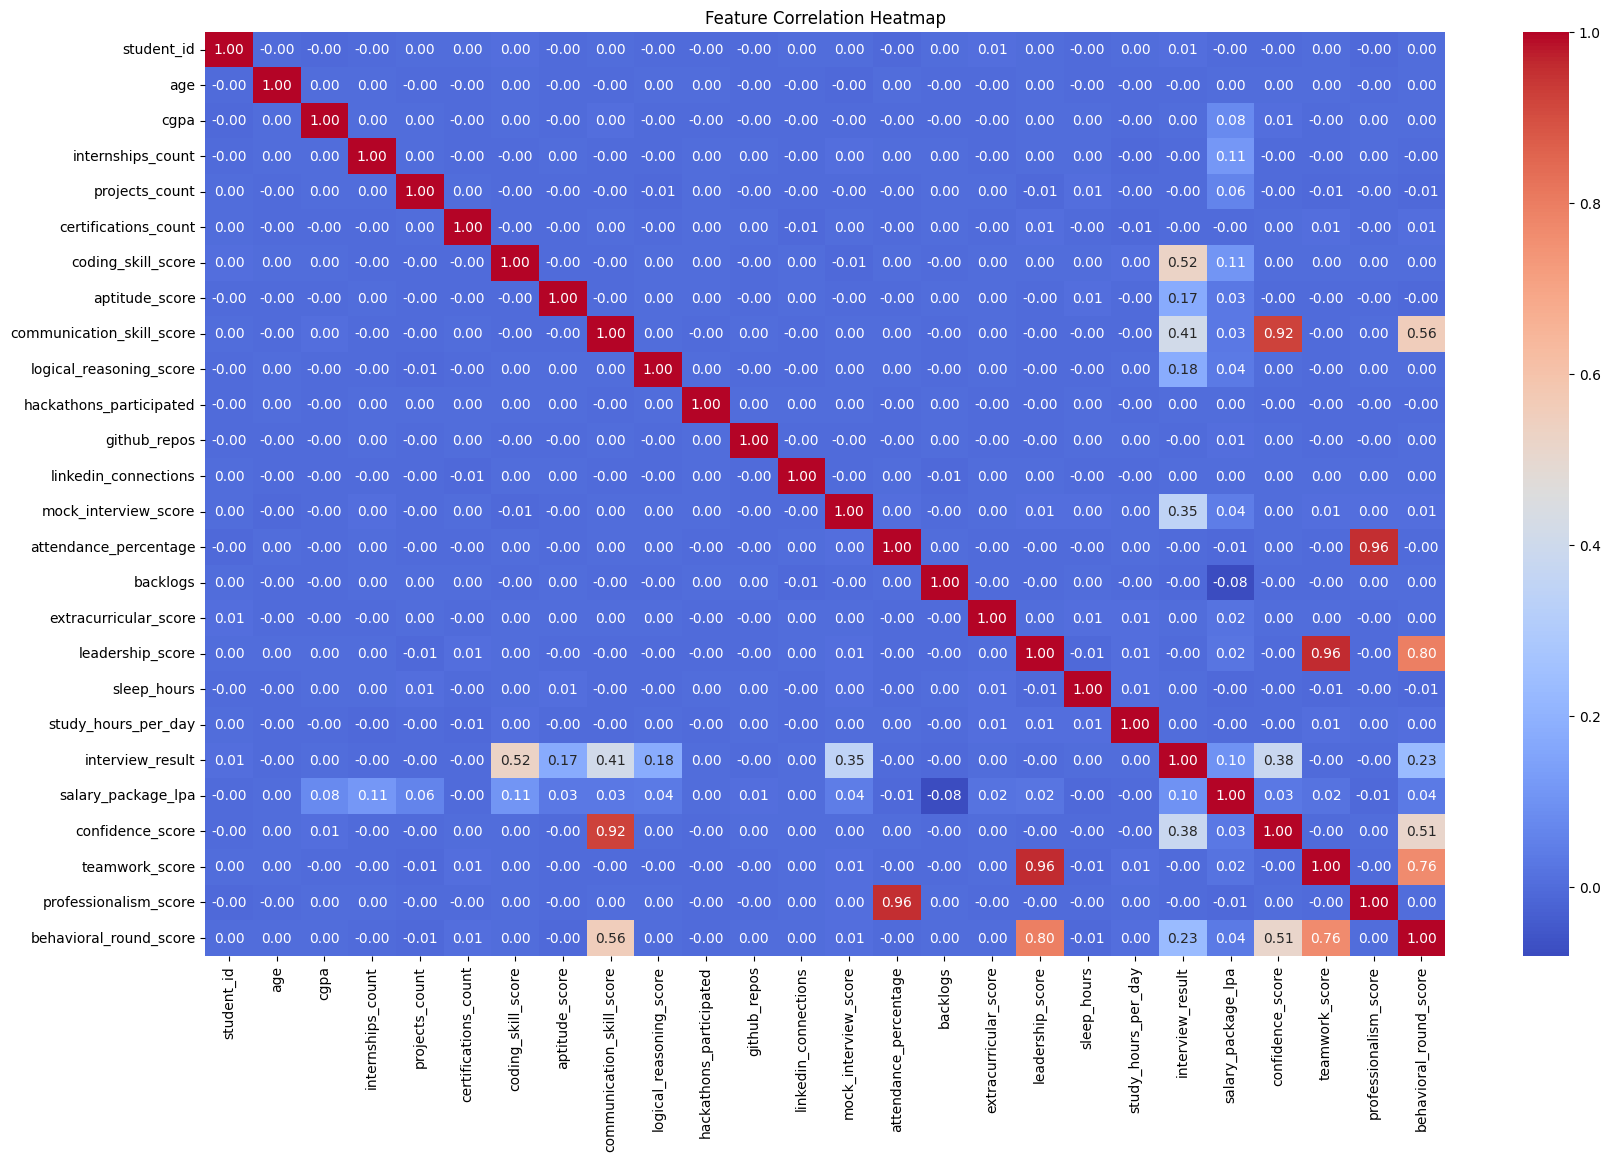

In [11]:
plt.figure(figsize=(20,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['interview_result'] = le.fit_transform(
    df['interview_result']
)

print(df['interview_result'].head())

0    1
1    0
2    1
3    1
4    1
Name: interview_result, dtype: int64


In [13]:
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.columns)

Index(['student_id', 'age', 'cgpa', 'internships_count', 'projects_count',
       'certifications_count', 'coding_skill_score', 'aptitude_score',
       'communication_skill_score', 'logical_reasoning_score',
       'hackathons_participated', 'github_repos', 'linkedin_connections',
       'mock_interview_score', 'attendance_percentage', 'backlogs',
       'extracurricular_score', 'leadership_score', 'sleep_hours',
       'study_hours_per_day', 'interview_result', 'salary_package_lpa',
       'confidence_score', 'teamwork_score', 'professionalism_score',
       'behavioral_round_score'],
      dtype='str')


In [14]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                           student_id       age      cgpa  internships_count  \
student_id                   1.000000 -0.003868 -0.004216          -0.001477   
age                         -0.003868  1.000000  0.004160           0.002791   
cgpa                        -0.004216  0.004160  1.000000           0.004149   
internships_count           -0.001477  0.002791  0.004149           1.000000   
projects_count               0.000687 -0.002062  0.004069           0.000625   
certifications_count         0.000299 -0.000056 -0.001269          -0.002689   
coding_skill_score           0.004721  0.000573  0.004129          -0.002755   
aptitude_score              -0.000300 -0.000839 -0.003143           0.000561   
communication_skill_score    0.001744 -0.000353  0.004439          -0.001777   
logical_reasoning_score     -0.001723  0.001009 -0.002373          -0.000275   
hackathons_participated     -0.001375  0.001321 -0.001778           0.000379   
github_repos                -0.001934 -0

In [15]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                           student_id       age      cgpa  internships_count  \
student_id                   1.000000 -0.003868 -0.004216          -0.001477   
age                         -0.003868  1.000000  0.004160           0.002791   
cgpa                        -0.004216  0.004160  1.000000           0.004149   
internships_count           -0.001477  0.002791  0.004149           1.000000   
projects_count               0.000687 -0.002062  0.004069           0.000625   
certifications_count         0.000299 -0.000056 -0.001269          -0.002689   
coding_skill_score           0.004721  0.000573  0.004129          -0.002755   
aptitude_score              -0.000300 -0.000839 -0.003143           0.000561   
communication_skill_score    0.001744 -0.000353  0.004439          -0.001777   
logical_reasoning_score     -0.001723  0.001009 -0.002373          -0.000275   
hackathons_participated     -0.001375  0.001321 -0.001778           0.000379   
github_repos                -0.001934 -0

In [16]:
target_correlation = correlation_matrix[
    'interview_result'
].sort_values(ascending=False)

print(target_correlation)

interview_result             1.000000
coding_skill_score           0.523857
communication_skill_score    0.412170
confidence_score             0.380861
mock_interview_score         0.346787
behavioral_round_score       0.228484
logical_reasoning_score      0.177726
aptitude_score               0.173601
salary_package_lpa           0.098467
student_id                   0.005252
cgpa                         0.004014
sleep_hours                  0.003819
extracurricular_score        0.003261
study_hours_per_day          0.002339
linkedin_connections         0.001813
hackathons_participated      0.000800
certifications_count        -0.000044
age                         -0.000655
internships_count           -0.001220
leadership_score            -0.001685
attendance_percentage       -0.001807
professionalism_score       -0.002234
github_repos                -0.002424
teamwork_score              -0.003677
projects_count              -0.003706
backlogs                    -0.004607
Name: interv

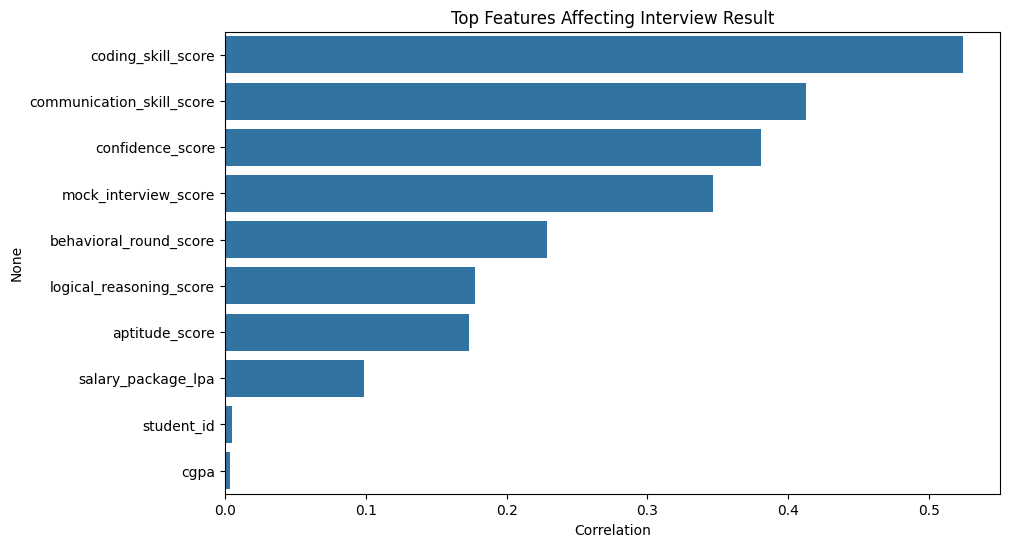

In [17]:
top_features = target_correlation[
    1:11
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title(
    "Top Features Affecting Interview Result"
)

plt.xlabel("Correlation")

plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(
    include='object'
).columns

print(categorical_columns)

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

Index(['gender', 'branch', 'college_tier', 'volunteer_experience'], dtype='str')
   student_id  age  gender  cgpa  branch  college_tier  internships_count  \
0           1   24       1  7.53       4             1                  4   
1           2   21       1  7.92       0             1                  1   
2           3   22       0  8.60       3             0                  0   
3           4   24       1  6.68       0             0                  0   
4           5   20       0  8.43       4             2                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   leadership_score  volunteer_experience  slee

C:\Users\23eg1\AppData\Local\Temp\ipykernel_29452\2129175883.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [26]:
interview_score = (
      df['coding_skill_score'] * 0.30
    + df['communication_skill_score'] * 0.25
    + df['mock_interview_score'] * 0.25
    + df['aptitude_score'] * 0.10
    + df['logical_reasoning_score'] * 0.10
)

df['interview_result'] = np.where(
    interview_score >= 70,
    1,
    0
)

print(df['interview_result'].value_counts())

interview_result
0    58436
1    41564
Name: count, dtype: int64


In [27]:
X = df[
    [
        'cgpa',
        'coding_skill_score',
        'communication_skill_score',
        'aptitude_score',
        'logical_reasoning_score',
        'mock_interview_score',
        'internships_count',
        'projects_count',
        'certifications_count',
        'confidence_score',
        'teamwork_score',
        'professionalism_score',
        'behavioral_round_score'
    ]
]

y = df['interview_result']

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy:
0.9991


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:")

print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy:
0.9622


In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

XGBoost Accuracy: 0.98335


In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     11766
           1       0.98      0.98      0.98      8234

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



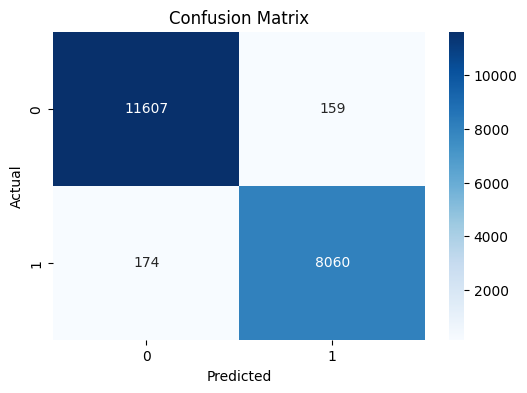

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(10)
)

                      Feature  Importance
1          coding_skill_score    0.286703
2   communication_skill_score    0.235295
5        mock_interview_score    0.181355
3              aptitude_score    0.118525
4     logical_reasoning_score    0.113915
9            confidence_score    0.019276
12     behavioral_round_score    0.008566
10             teamwork_score    0.007698
8        certifications_count    0.006790
0                        cgpa    0.005811


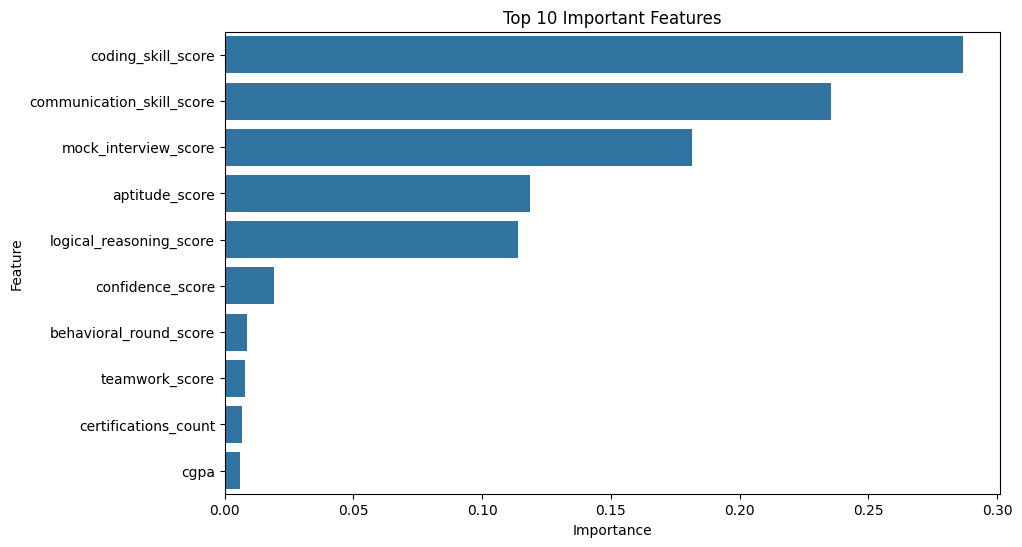

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [40]:
import joblib

joblib.dump(
    xgb_model,
    'model.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

print("Final Model Saved")

Final Model Saved
